In [20]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## 图像梯度
### Sobel 算子

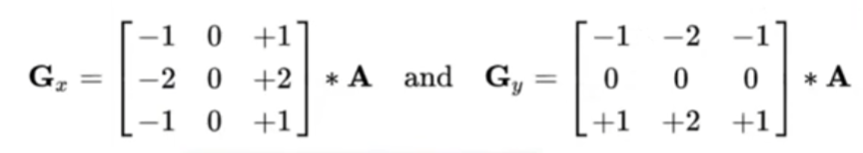

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(<Axes: title={'center': 'sobelxy_c'}>,
 Text(0.5, 1.0, 'sobelxy_c'),
 (-0.5, 1278.5, 1705.5, -0.5))

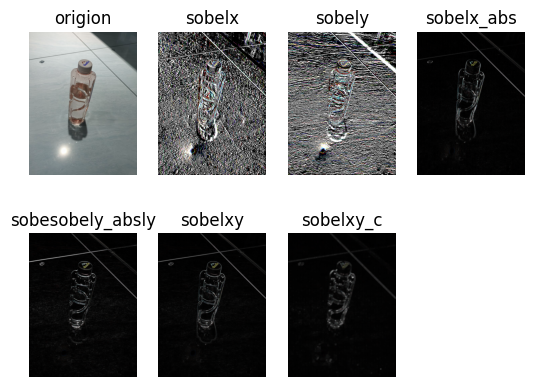

In [ ]:
img = cv2.imread('./assets/1.jpg')

# @param ddepth 图像深度（不对 0 截断为0，cv2.CV_64F 包括负数）
# @param dx 水平方向
# @param dy 竖直方向
# @param ksize Sobel 算子大小
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize = 3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize = 3)
sobelx_abs = cv2.convertScaleAbs(sobelx)
sobely_abs = cv2.convertScaleAbs(sobely)
# 0：这是一个偏置项（加到最终结果中的常数），通常用于调节输出图像的亮度
sobelxy = cv2.addWeighted(sobelx_abs, 0.5, sobely_abs, 0.5, 0)
# 不建议 x, y 同时算，效果不好，有重影
sobelxy_c = cv2.Sobel(img, cv2.CV_64F, 1, 1, ksize = 3)
sobelxy_c_abs = cv2.convertScaleAbs(sobelxy_c)
kernel = np.ones((5, 5), np.uint8)
sobelxy_c_dilate = cv2.dilate(sobelxy_c_abs, kernel, iterations = 3)

plt.subplot(241), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(242), plt.imshow(sobelx), plt.title("sobelx"), plt.axis('off')
plt.subplot(243), plt.imshow(sobely), plt.title("sobely"), plt.axis('off')
plt.subplot(244), plt.imshow(sobelx_abs), plt.title("sobelx_abs"), plt.axis('off')
plt.subplot(245), plt.imshow(sobely_abs), plt.title("sobesobely_absly"), plt.axis('off')
plt.subplot(246), plt.imshow(sobelxy), plt.title("sobelxy"), plt.axis('off')
plt.subplot(247), plt.imshow(sobelxy_c_dilate), plt.title("sobelxy_c"), plt.axis('off')

### Scharr 算子

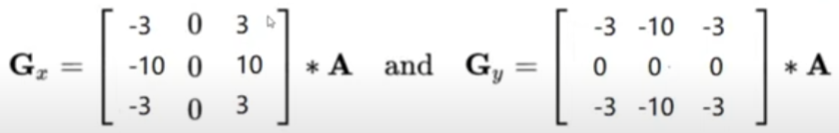

### laplacian 算子

- 二阶导，一阶导的变化率，对变化更敏感
    - 对噪音点更敏感，通常需要结合其他方法一起使用

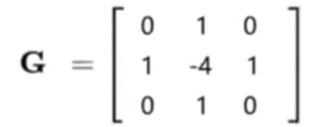

(<Axes: title={'center': 'lap_dilate'}>,
 Text(0.5, 1.0, 'lap_dilate'),
 (-0.5, 1278.5, 1705.5, -0.5))

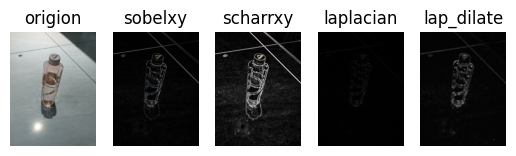

In [28]:
img = cv2.imread('./assets/1.jpg')

sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize = 3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize = 3)
sobelx_abs = cv2.convertScaleAbs(sobelx)
sobely_abs = cv2.convertScaleAbs(sobely)
sobelxy = cv2.addWeighted(sobelx_abs, 0.5, sobely_abs, 0.5, 0)

scharrx = cv2.Scharr(img, cv2.CV_64F, 1, 0)
scharry = cv2.Scharr(img, cv2.CV_64F, 0, 1)
scharrx_abs = cv2.convertScaleAbs(scharrx)
scharry_abs = cv2.convertScaleAbs(scharry)
scharrxy = cv2.addWeighted(scharrx_abs, 0.5, scharry_abs, 0.5, 0)

laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian_abs = cv2.convertScaleAbs(laplacian)

kernel = np.ones((5, 5), np.uint8)
laplacian_dilate = cv2.dilate(laplacian_abs, kernel, iterations = 3)

plt.subplot(251), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(252), plt.imshow(sobelxy), plt.title("sobelxy"), plt.axis('off')
plt.subplot(253), plt.imshow(scharrxy), plt.title("scharrxy"), plt.axis('off')
plt.subplot(254), plt.imshow(laplacian_abs), plt.title("laplacian"), plt.axis('off')
plt.subplot(255), plt.imshow(laplacian_dilate), plt.title("lap_dilate"), plt.axis('off')